In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack
import fitsio
import scipy.spatial.transform as trans
from desimodel.footprint import is_point_in_desi
import astropy.io.ascii
from scipy.spatial import cKDTree
from astropy.cosmology import Planck18 as cosmo
import astropy.units as u
from CountsinCylinders import *

In [2]:
#set up auto-reload for development purposes

%load_ext autoreload
%autoreload 2

In [3]:
def MCintegrateholes(randtable,holetable,mask,maskargs,R_hole):
    rands = randtable[mask(randtable,*maskargs)]
    rands['UScoord'] = raDecToUnitSphere(rands['RA'],rands['DEC'])
    randUSmap = [coord[:3] for coord in rands['UScoord']]
    randtree_US = cKDTree(randUSmap)

    
    holemap = [[holetable['x'][i],holetable['y'][i],holetable['z'][i]] for i in range(len(holetable))]
    holetree = cKDTree(holemap)

    holeneighbors = randtree_US.query_ball_tree(holetree,R_hole)
    holemask = [len(n) < 1 for n in holeneighbors]
    randcleaned = rands[holemask]

    return len(randcleaned)/len(rands)

In [4]:
def MCintegrateholesGraphics(randtable,holetable,mask,maskargs,R_hole,xlim,ylim):
    rands = randtable[mask(randtable,*maskargs)]
    rands['UScoord'] = raDecToUnitSphere(rands['RA'],rands['DEC'])
    randUSmap = [coord[:3] for coord in rands['UScoord']]
    randtree_US = cKDTree(randUSmap)

    
    holemap = [[holetable['x'][i],holetable['y'][i],holetable['z'][i]] for i in range(len(holetable))]
    holetree = cKDTree(holemap)

    holeneighbors = randtree_US.query_ball_tree(holetree,R_hole)
    holemask = [len(n) < 1 for n in holeneighbors]
    randcleaned = rands[holemask]
    randelim = rands[[not h for h in holemask]]
    plt.scatter(rands['RA'],rands['DEC'],s=0.1,label = "Randoms after Mask")
    plt.scatter(holetable['RA'],holetable['DEC'],label = 'Holes',s=0.1)
    plt.scatter(randelim['RA'],randelim['DEC'],s=1,color='red',label = "Eliminated Randoms")
    plt.legend(loc = 'upper right')

    plt.figure()
    plt.hist(rands['RSDZ'])
    plt.hist(randcleaned['RSDZ'])
    #plt.xlim(*xlim)
    #plt.ylim(*ylim)

    return len(randcleaned)/len(rands)

In [5]:
def getnZ(table,solidangle,zlim,nbins,zname = "Z"):
    bins = np.linspace(*zlim,num=nbins)
    hist, bins = np.histogram(table[zname],bins)
    nz = []
    for i in range(len(bins)-1):
        d1 = cosmo.comoving_distance(bins[i+1])/u.Mpc
        d2 = cosmo.comoving_distance(bins[i])/u.Mpc
        v = 1/3*solidangle*(d1**3-d2**3)
        nz.append(hist[i]/v/cosmo.h**3)
    return nz,bins

## Check what fraction of the sky is blocked by holes ##

In [6]:
#Load randoms that do not have any holes

randir = "/global/cfs/cdirs/desi/target/catalogs/dr9/0.49.0/randoms/resolve/"
rantables = []
for i in range(1):
    ranfile = randir + "randoms-1-"+str(i)+".fits"
    rantab = Table(fitsio.read(ranfile,columns=['RA','DEC','MASKBITS']))
    rantables.append(rantab)
rantable = vstack(rantables)
rantable['RA'] = rantable['RA']+1

In [7]:
#loadholes
holetableselg = []
holetableslrg = []
for i in range(117):
    spelg = Table.read("datafiles/Holes_ELG_SV3_tile"+str(i)+"_holes.csv",format = "csv")
    splrg = Table.read("datafiles/Holes_LRG_SV3_tile"+str(i)+"_holes.csv",format = "csv")
    holetableselg.append(spelg)
    holetableslrg.append(splrg)
holetableelg = vstack(holetableselg)
holetablelrg = vstack(holetableslrg)
print(len(holetableelg),len(holetablelrg))

4646361 4697603


In [8]:
'''holetableelg['RA'],holetableelg['DEC'] = UnitSphereToRaDecPosRA(holetableelg['x'],holetableelg['y'],holetableelg['z'])
holetablelrg['RA'],holetablelrg['DEC'] = UnitSphereToRaDecPosRA(holetablelrg['x'],holetablelrg['y'],holetablelrg['z'])'''

"holetableelg['RA'],holetableelg['DEC'] = UnitSphereToRaDecPosRA(holetableelg['x'],holetableelg['y'],holetableelg['z'])\nholetablelrg['RA'],holetablelrg['DEC'] = UnitSphereToRaDecPosRA(holetablelrg['x'],holetablelrg['y'],holetablelrg['z'])"

In [9]:
#SV3 pass fraction
#for debugging purposes
'''
rosettes['RAmin'] = np.array(rosettes['RA']) - 1/np.cos(np.array(rosettes['DEC']))*2
rosettes['RAmax'] = np.array(rosettes['RA']) + 1/np.cos(np.array(rosettes['DEC']))*2
rosettes['DECmin'] = np.array(rosettes['DEC']) - 2
rosettes['DECmax'] = np.array(rosettes['DEC']) + 2
psilim = [0.2,1.5]
mask = rosetteOR
R_hole = R_hole = 0.03*np.pi/180 #convert from degrees to radians
for i in range(1):
    xlim = [rosettes['RAmin'][i],rosettes['RAmax'][i]]
    ylim = [rosettes['DECmin'][i],rosettes['DECmax'][i]]
    rosette = {'RA': [rosettes['RA'][i]], 'DEC': [rosettes['DEC'][i]], 'ID': [rosettes['ID'][i]]}
    maskargs = [*psilim, rosette,'RA','DEC']
    elgpass = MCintegrateholesGraphics(rantable,holetableelg,mask,maskargs,R_hole,xlim,ylim)
    lrgpass = MCintegrateholesGraphics(rantable,holetablelrg,mask,maskargs,R_hole,xlim,ylim)
    print("Fraction of sky not blocked by holes, SV3")
    print("ELGs: ",elgpass)
    print("LRGs: ",lrgpass)

'''
#for real calculation
#SV3 pass fraction
psilim = [0.2,1.5]
mask = rosetteOR
R_hole = R_hole = 0.03*np.pi/180 #convert from degrees to radians
#rosette = {'RA': [rosettes['RA'][i]], 'DEC': [rosettes['DEC'][i]], 'ID': [rosettes['ID'][i]]}
maskargs = [*psilim, rosettes,'RA','DEC']
elgpass = MCintegrateholes(rantable,holetableelg,mask,maskargs,R_hole)
lrgpass = MCintegrateholes(rantable,holetablelrg,mask,maskargs,R_hole)
print("Fraction of sky not blocked by holes, SV3")
print("ELGs: ",elgpass)
print("LRGs: ",lrgpass)

Fraction of sky not blocked by holes, SV3
ELGs:  0.8731361997354001
LRGs:  0.8385133986089773


## Abacus ##

In [10]:
#loadholes
holetableselg = []
holetableslrg = []
for i in range(240):
    spelg = Table.read("datafiles/forFAelg_tile"+str(i)+"_holes.csv",format = "csv")
    splrg = Table.read("datafiles/forFAlrg_tile"+str(i)+"_holes.csv",format = "csv")
    holetableselg.append(spelg)
    holetableslrg.append(splrg)
holetableelg = vstack(holetableselg)
holetablelrg = vstack(holetableslrg)
print(len(holetableelg),len(holetablelrg))

2218580 2349008


In [45]:
holetableelg['RA'],holetableelg['DEC'] = UnitSphereToRaDecPosRA(holetableelg['x'],holetableelg['y'],holetableelg['z'])

In [48]:
holetablelrg['RA'],holetablelrg['DEC'] = UnitSphereToRaDecPosRA(holetablelrg['x'],holetablelrg['y'],holetablelrg['z'])

In [52]:
#Abacus pass fraction
ralim = [130,223]
declim  = [-5.25,3.75]

maskargs = [*ralim,*declim]
xlim = [125,135]
ylim = [-5.25,0]
mask = angularCut
R_hole = 0.03*np.pi/180 #convert from degrees to radians

elgpassAbacus = MCintegrateholes(rantable,holetablelrg,mask,maskargs,R_hole)
lrgpassAbacus = MCintegrateholes(rantable,holetablelrg,mask,maskargs,R_hole)

In [15]:
#plt.hist(holetableelg['DEC'],bins=50)

In [16]:
'''rancut = rantable[(rantable['RA'] > ralim[0])&(rantable['RA'] < ralim[1])&(rantable['DEC'] > declim[0])&(rantable['DEC'] < declim[1])]
UScoord = raDecToUnitSphere(rancut['RA'][::100],rancut['DEC'][::100])'''

"rancut = rantable[(rantable['RA'] > ralim[0])&(rantable['RA'] < ralim[1])&(rantable['DEC'] > declim[0])&(rantable['DEC'] < declim[1])]\nUScoord = raDecToUnitSphere(rancut['RA'][::100],rancut['DEC'][::100])"

In [17]:
'''ranx = [coo[0] for coo in UScoord]
rany = [coo[1] for coo in UScoord]
ranz = [coo[2] for coo in UScoord]'''

'ranx = [coo[0] for coo in UScoord]\nrany = [coo[1] for coo in UScoord]\nranz = [coo[2] for coo in UScoord]'

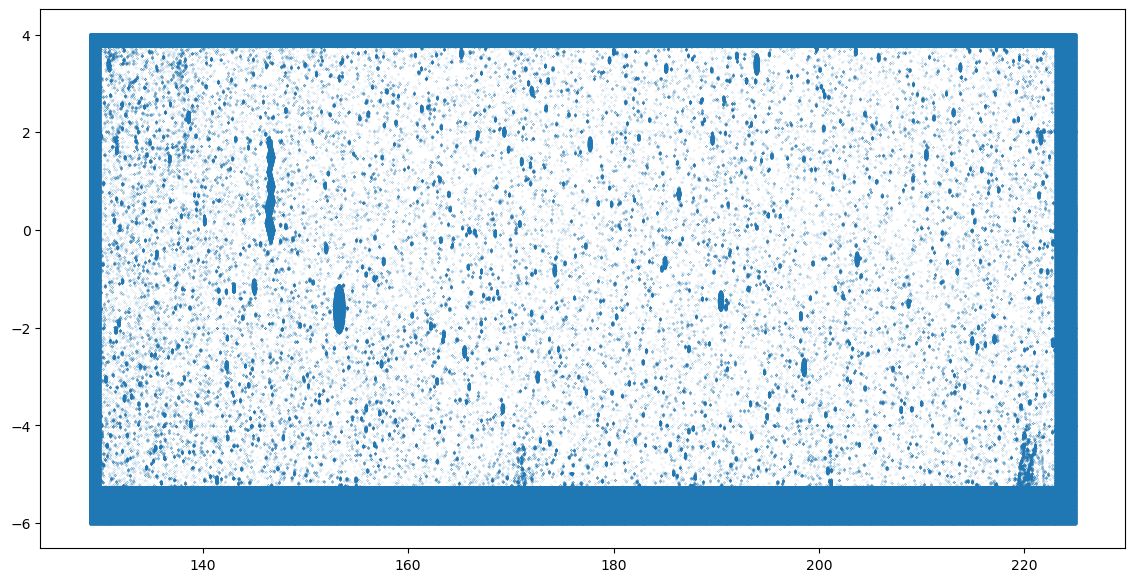

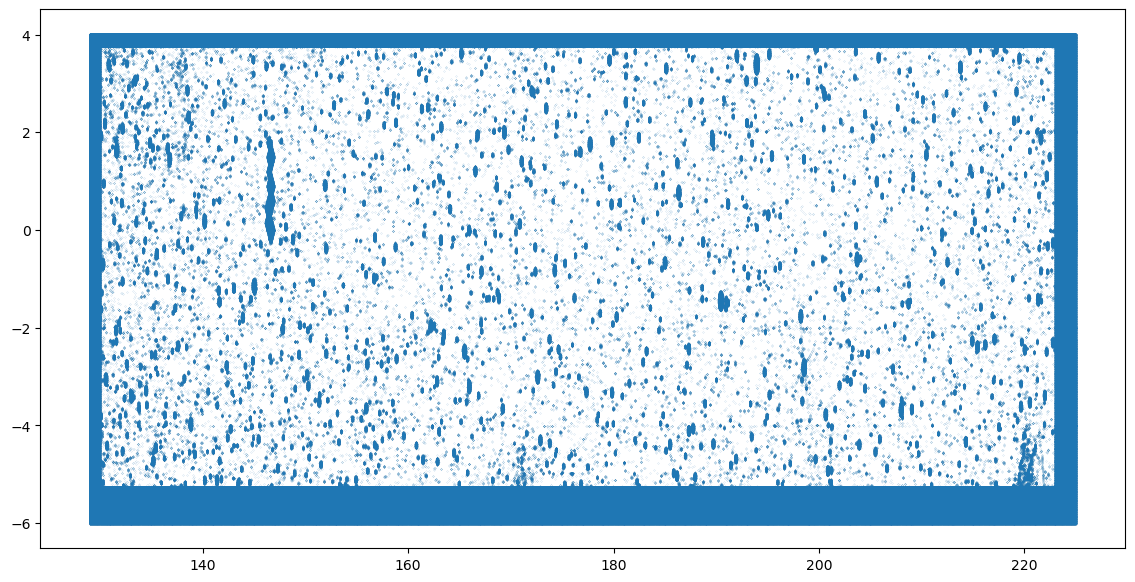

In [51]:
#fig = plt.figure(figsize=(14,7))
#ax = fig.add_subplot(projection='3d')
plt.figure(figsize=(14,7))
plt.scatter(holetableelg['RA'],holetableelg['DEC'],s=0.005)
plt.figure(figsize=(14,7))
plt.scatter(holetablelrg['RA'],holetablelrg['DEC'],s=0.005)
#ax.scatter(ranx,rany,ranz)'''

In [19]:
'''plt.xlim(135,140)
plt.ylim(-5,0)
plt.scatter(holetablelrg['RA'],holetablelrg['DEC'],s=1,alpha=0.5)
plt.scatter(holetableelg['RA'],holetableelg['DEC'],s=1,alpha=0.5)'''


"plt.xlim(135,140)\nplt.ylim(-5,0)\nplt.scatter(holetablelrg['RA'],holetablelrg['DEC'],s=1,alpha=0.5)\nplt.scatter(holetableelg['RA'],holetableelg['DEC'],s=1,alpha=0.5)"

In [53]:
print("Fraction of sky not blocked by holes, Abacus")
print("ELGs: ",elgpassAbacus)
print("LRGs: ",lrgpassAbacus)

Fraction of sky not blocked by holes, Abacus
ELGs:  0.8772861289150519
LRGs:  0.8772861289150519


In [21]:
#area enlosed by ra,dec limits
ralimrad = np.pi/180*np.array(ralim)
declimrad = np.pi/180*np.array(declim)

areaAbacus = (np.sin(declimrad[1])-np.sin(declimrad[0]))*(ralimrad[1]-ralimrad[0])
print(areaAbacus)

#area enclosed by rosette limits
psilimrad = np.pi/180*np.array(psilim)

areaSV3=2*np.pi*(np.cos(psilimrad[0])-np.cos(psilimrad[1]))*20
print(areaSV3)

0.25468091503612245
0.042296227273166336


In [54]:
nELG_SV3 = 44815 #38028 #46513 #46513 #42992 #41421 prev       #48133 #70810
nLRG_SV3 =  26569 #19843 # 28229 prev
nELG_Abacus = 336321 #332249 #287809 #247554 #as of 8/11, not sure where prev number comes from #287809 #332249 prev
nLRG_Abacus = 167450 #162392 #146369 #167450 prev

In [55]:
Abacusdensity_elg = nELG_Abacus/(elgpassAbacus*areaAbacus)
Abacusdensity_lrg = nLRG_Abacus/(lrgpassAbacus*areaAbacus)
SV3density_elg = nELG_SV3/(elgpass*areaSV3)
SV3density_lrg = nLRG_SV3/(lrgpass*areaSV3)

In [56]:
print(SV3density_elg/Abacusdensity_elg)
print(SV3density_lrg/Abacusdensity_lrg)

0.8061640995578366
0.9995766062672146


In [42]:
#check number density
print((elgpassAbacus*areaAbacus),(lrgpassAbacus*areaAbacus),(elgpass*areaSV3),(lrgpass*areaSV3))


0.2205489466458694 0.2234280340605831 0.03693036714443724 0.035465953279160425


## Old Stuff ##

In [4]:
randir = "/global/cfs/cdirs/desi/target/catalogs/dr9/0.49.0/randoms/resolve/"
rantables = []
for i in range(1):
    ranfile = randir + "randoms-1-"+str(i)+".fits"
    rantab = Table(fitsio.read(ranfile,columns=['RA','DEC','MASKBITS']))
    rantables.append(rantab)
rantable = vstack(rantables)
rantable['RA'] = rantable['RA']+1 #to remove correlation with holes catalogs, which were developed with the same set of randoms

In [5]:
#load holes
holetableselg = []
holetableslrg = []
for i in range(240):
    spelg = Table.read("datafiles/forFAelg_tile"+str(i)+"_holes.csv",format = "csv")
    splrg = Table.read("datafiles/forFAlrg_tile"+str(i)+"_holes.csv",format = "csv")
    holetableselg.append(spelg)
    holetableslrg.append(splrg)
holetableelg = vstack(holetableselg)
holetablelrg = vstack(holetableslrg)

In [6]:
ralim = [130,223]
declim  = [-5.25,3.75]

maskargs = [*ralim,*declim]

mask = angularCut
R_hole = 0.03*np.pi/180 #convert from degrees to radians

elgpass = MCintegrateholes(rantable,holetableelg,mask,maskargs,R_hole)
lrgpass = MCintegrateholes(rantable,holetablelrg,mask,maskargs,R_hole)

In [8]:
sv3elg = Table.read("datafiles/SV3cleaned_R1L40_elg.csv")
sv3lrg = Table.read("datafiles/SV3cleaned_R1L40_lrg.csv")

sv3elg_ros = [sv3elg[(sv3elg['rosette'] == i)] for i in np.arange(1,21)]
sv3lrg_ros = [sv3lrg[(sv3lrg['rosette'] == i)] for i in np.arange(1,21)]

sv3elg_ros88 = [sv3elg[(sv3elg['rosette'] == i)&(sv3elg['Z'] > 0.88)] for i in np.arange(1,21)]

R_CiC = "1"
complete_elg = []
complete_lrg = []
for mocknumber in np.arange(10):
    complete_elg.append(Table.read("datafiles/AbacusComplete_cleaned_"+str(mocknumber)+"_R1L40_elg.csv",format='csv'))
    complete_lrg.append(Table.read("datafiles/AbacusComplete_cleaned_"+str(mocknumber)+"_R1L40_lrg.csv",format='csv'))

sv3elg_notqso = Table.read("datafiles/SV3notqso_R1L40_elg.csv")
sv3lrg_notqso = Table.read("datafiles/SV3notqso_R1L40_lrg.csv")

#forFA, cleaned
forFA_elg = []
forFA_lrg = []
for mocknumber in np.arange(10):
    forFA_elg.append(Table.read("datafiles/forFA_noebits_cleaned_"+str(mocknumber)+"_R"+str(R_CiC)+"L40_elg.csv",format='csv'))
    forFA_lrg.append(Table.read("datafiles/forFA_noebits_cleaned_"+str(mocknumber)+"_R"+str(R_CiC)+"L40_lrg.csv",format='csv'))

#Uchuu, cleaned
uchuu_elg = []
uchuu_lrg = []
for mocknumber in np.arange(102):
    uchuu_elg.append(Table.read("datafiles/Uchuu_cleaned_"+str(mocknumber)+"R"+str(R_CiC)+"L40_elg.csv",format='csv'))
    uchuu_lrg.append(Table.read("datafiles/Uchuu_cleaned_"+str(mocknumber)+"R"+str(R_CiC)+"L40_lrg.csv",format='csv'))


#Abacus, N(z) matched

#for paper
Abacusnzadj_elg = []
Abacusnzadj_lrg = []
for mocknumber in np.arange(10):
    name="forFA_noebits_cleaned_nzadjusted_"+str(mocknumber)+"_R"+str(R_CiC)+"L40"
    Abacusnzadj_elg.append(Table.read("datafiles/"+name+"_elg.csv",format='csv'))
    Abacusnzadj_lrg.append(Table.read("datafiles/"+name+"_lrg.csv",format='csv'))   

In [9]:
solidangle = 0.042296227273166336*0.9067233610305354
zlim = [0.75695,0.9919]
nbins=20
nzsv3 , bins = getnZ(sv3elg,solidangle,zlim,nbins,zname = "Z")
nzsv3notqso , bins = getnZ(sv3elg_notqso,solidangle,zlim,nbins,zname = "Z")
nzuchuu , bins = getnZ(uchuu_elg[0],solidangle,zlim,nbins)

solidangle = 0.042296227273166336*0.8893598303401511
nzsv3lrg , bins = getnZ(sv3lrg,solidangle,zlim,nbins,zname = "Z")
nzuchuulrg , bins = getnZ(uchuu_lrg[0],solidangle,zlim,nbins)


solidangle = 0.25468091503612245*0.8670951197000233
nzcomplete, bins = getnZ(complete_elg[0],solidangle,zlim,nbins)
nzforFA, bins = getnZ(forFA_elg[0],solidangle,zlim,nbins,zname="RSDZ")
nzforFAlrg, bins = getnZ(forFA_lrg[0],solidangle,zlim,nbins,zname="RSDZ")
nzcompletelrg, bins = getnZ(complete_lrg[1],solidangle,zlim,nbins)
nzabacusadj_elg,bins = getnZ(Abacusnzadj_elg[0],solidangle,zlim,nbins,zname="RSDZ")
nzabacusadj_lrg,bins = getnZ(Abacusnzadj_lrg[0],solidangle,zlim,nbins,zname="RSDZ")

#nz factors
nzfactorselg = []
nzfactorslrg = []
for i in range(20):
    nzlrgf = len(sv3lrg_ros[i])/len(sv3lrg)*20
    nzelgf = len(sv3elg_ros[i])/len(sv3elg)*20
    nzfactorselg.append(nzelgf)
    nzfactorslrg.append(nzlrgf)

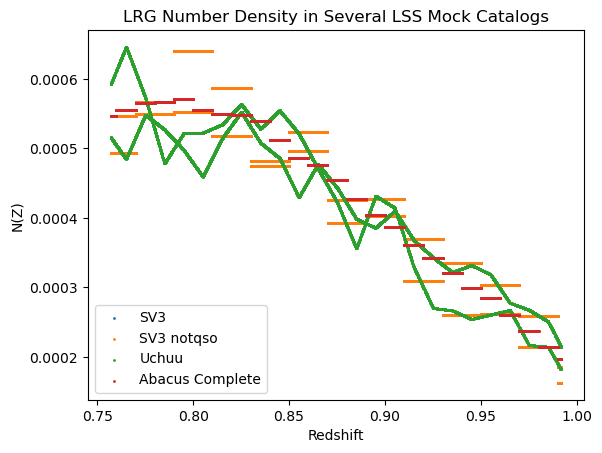

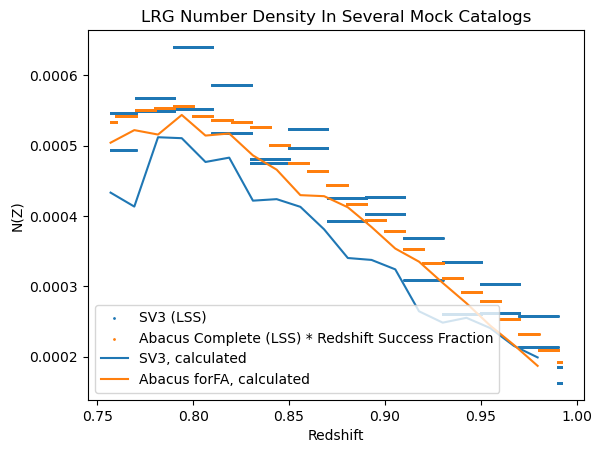

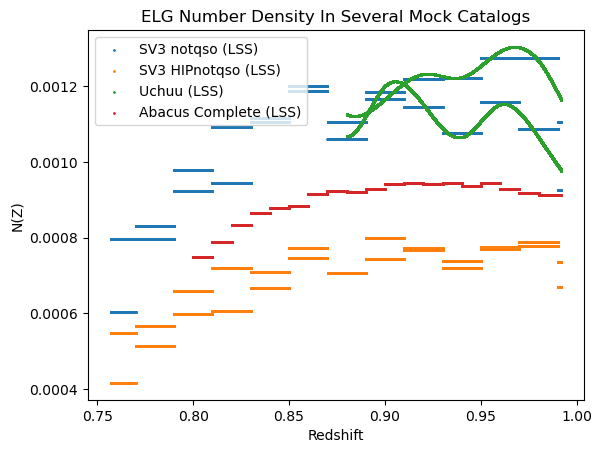

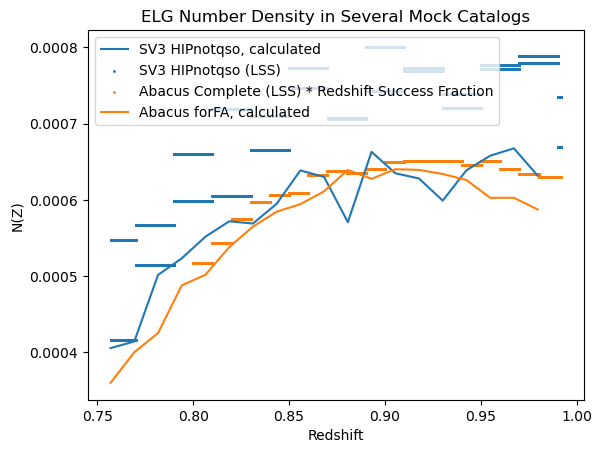

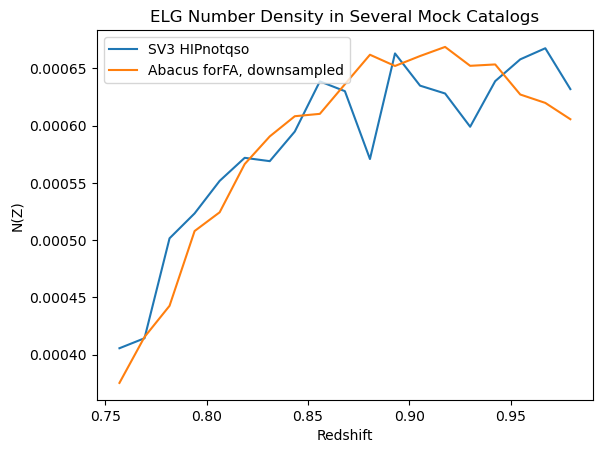

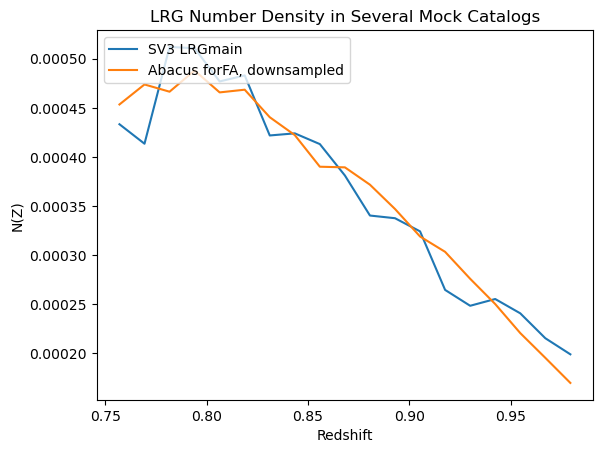

In [10]:
complrg = complete_lrg[8]
uchlrg = uchuu_lrg[8]#vstack(uchuu_elg)

compelg = complete_elg[8]
uchelg = uchuu_elg[8]#vstack(uchuu_elg)
'''
plt.hist(uch['Z'])

forFA = forFA_elg[8]

plt.hist(forFA['RSDZ'])
'''
plt.figure()
plt.title("LRG Number Density in Several LSS Mock Catalogs")
plt.scatter(sv3lrg['Z'],sv3lrg['NZ'],label = "SV3",s=1)
plt.scatter(sv3lrg_notqso['Z'],sv3lrg_notqso['NZ'],label = "SV3 notqso",s=1)
plt.scatter(uchlrg['Z'],uchlrg['NZ'],label = "Uchuu",s=1)
plt.scatter(complrg['Z'],complrg['NX'],label = "Abacus Complete",s=1)
plt.xlabel("Redshift")
plt.ylabel("N(Z)")
plt.legend(loc='lower left')

plt.figure()
plt.title("LRG Number Density In Several Mock Catalogs")
plt.scatter(sv3lrg['Z'],sv3lrg['NZ'],label = "SV3 (LSS)",s=1)
plt.scatter(complrg['Z'],complrg['NX']*0.976,label = "Abacus Complete (LSS) * Redshift Success Fraction",s=1)
plt.plot(bins[:-1],nzsv3lrg,label="SV3, calculated")
#plt.plot(bins[:-1],np.array(nzcompletelrg)*0.976,label="Abacus Complete * Redshift Success Fraction")
plt.plot(bins[:-1],np.array(nzforFAlrg)*0.976,label="Abacus forFA, calculated")
#plt.plot(bins[:-1],np.array(nzuchuulrg)*0.976,label="Uchuu")
plt.xlabel("Redshift")
plt.ylabel("N(Z)")
plt.legend()

plt.figure()
plt.title("ELG Number Density In Several Mock Catalogs")         
plt.scatter(sv3elg_notqso['Z'],sv3elg_notqso['NZ'],label = "SV3 notqso (LSS)",s=1)
plt.scatter(sv3elg['Z'],sv3elg['NZ'],label = "SV3 HIPnotqso (LSS)",s=1)
plt.scatter(uchelg['Z'],uchelg['NZ'],label = "Uchuu (LSS)",s=1)
plt.scatter(compelg['Z'],compelg['NX'],label = "Abacus Complete (LSS)",s=1)
plt.xlabel("Redshift")
plt.ylabel("N(Z)")
plt.legend(loc='upper left')

plt.figure()
plt.title("ELG Number Density in Several Mock Catalogs")
#plt.plot(bins[:-1],nzsv3notqso,label="SV3 (notqso)")
plt.plot(bins[:-1],nzsv3,label="SV3 HIPnotqso, calculated")
#plt.plot(bins[:-1],nzuchuu,label="Uchuu")
#plt.plot(bins[:-1],np.array(nzcomplete)*0.69,label="Abacus Complete * Redshift Success Fraction")
plt.scatter(sv3elg['Z'],sv3elg['NZ'],label = "SV3 HIPnotqso (LSS)",s=1)
plt.scatter(compelg['Z'],compelg['NX']*0.69,label = "Abacus Complete (LSS) * Redshift Success Fraction",s=1)
plt.plot(bins[:-1],nzforFA,label="Abacus forFA, calculated")
#plt.scatter(sv3elg_notqso['Z'],sv3elg_notqso['NZ'],label = "SV3 notqso (LSS)",s=1,color = 'blue')
plt.xlabel("Redshift")
plt.ylabel("N(Z)")

plt.legend(loc='upper left')


#adjusted number density
plt.figure()
plt.title("ELG Number Density in Several Mock Catalogs")
#plt.plot(bins[:-1],nzsv3notqso,label="SV3 (notqso)")
plt.plot(bins[:-1],nzsv3,label="SV3 HIPnotqso")
plt.plot(bins[:-1],nzabacusadj_elg,label="Abacus forFA, downsampled")
#plt.scatter(sv3elg_notqso['Z'],sv3elg_notqso['NZ'],label = "SV3 notqso (LSS)",s=1,color = 'blue')
plt.xlabel("Redshift")
plt.ylabel("N(Z)")

plt.legend(loc='upper left')


plt.figure()
plt.title("LRG Number Density in Several Mock Catalogs")
#plt.plot(bins[:-1],nzsv3notqso,label="SV3 (notqso)")
plt.plot(bins[:-1],nzsv3lrg,label="SV3 LRGmain")
#plt.plot(bins[:-1],nzuchuu,label="Uchuu")
#plt.plot(bins[:-1],np.array(nzcomplete)*0.69,label="Abacus Complete * Redshift Success Fraction")
plt.plot(bins[:-1],nzabacusadj_lrg,label="Abacus forFA, downsampled")
#plt.scatter(sv3elg_notqso['Z'],sv3elg_notqso['NZ'],label = "SV3 notqso (LSS)",s=1,color = 'blue')
plt.xlabel("Redshift")
plt.ylabel("N(Z)")

plt.legend(loc='upper left')
#plt.ylim(0,0.001)

In [11]:
#just get the overall number density

nbins= 2
solidangle = 0.042296227273166336*0.9067233610305354
zlim = [0.75695,0.9919]
nzsv3 , bins = getnZ(sv3elg,solidangle,zlim,nbins,zname = "Z")

solidangle = 0.042296227273166336*0.8893598303401511
nzsv3lrg , bins = getnZ(sv3lrg,solidangle,zlim,nbins,zname = "Z")


solidangle = 0.25468091503612245*0.8670951197000233
#nzcomplete, bins = getnZ(complete_elg[0],solidangle,zlim,nbins)
nzforFA, bins = getnZ(forFA_elg[0],solidangle,zlim,nbins,zname="RSDZ")
nzforFAlrg, bins = getnZ(forFA_lrg[0],solidangle,zlim,nbins,zname="RSDZ")

'''
#nz factors
nzfactorselg = []
nzfactorslrg = []
for i in range(20):
    nzlrgf = len(sv3lrg_ros[i])/len(sv3lrg)*20
    nzelgf = len(sv3elg_ros[i])/len(sv3elg)*20
    nzfactorselg.append(nzelgf)
    nzfactorslrg.append(nzlrgf)'''

print(nzsv3,nzsv3lrg,nzforFA,nzforFAlrg)

print("downsample forFA LRG by: ")
print(nzsv3lrg[0]/nzforFAlrg[0])
print("downsample SV3 ELG by: ")
print(nzforFA[0]/nzsv3[0])

[<Quantity 0.00058881>] [<Quantity 0.00035569>] [<Quantity 0.00056688>] [<Quantity 0.00040363>]
downsample forFA LRG by: 
0.8812216895357733
downsample SV3 ELG by: 
0.9627664301054767


In [12]:
#just get the overall number density

nbins= 2
solidangle = 0.042296227273166336*0.9067233610305354
zlim = [0.75695,0.9919]
nzsv3 , bins = getnZ(sv3elg,solidangle,zlim,nbins,zname = "Z")

solidangle = 0.042296227273166336*0.8893598303401511
nzsv3lrg , bins = getnZ(sv3lrg,solidangle,zlim,nbins,zname = "Z")


solidangle = 0.25468091503612245*0.8670951197000233
#nzcomplete, bins = getnZ(complete_elg[0],solidangle,zlim,nbins)
nzforFA, bins = getnZ(Abacusnzadj_elg[0],solidangle,zlim,nbins,zname="RSDZ")
nzforFAlrg, bins = getnZ(Abacusnzadj_lrg[0],solidangle,zlim,nbins,zname="RSDZ")

'''
#nz factors
nzfactorselg = []
nzfactorslrg = []
for i in range(20):
    nzlrgf = len(sv3lrg_ros[i])/len(sv3lrg)*20
    nzelgf = len(sv3elg_ros[i])/len(sv3elg)*20
    nzfactorselg.append(nzelgf)
    nzfactorslrg.append(nzlrgf)'''

print(nzsv3,nzsv3lrg,nzforFA,nzforFAlrg)

[<Quantity 0.00058881>] [<Quantity 0.00035569>] [<Quantity 0.00058863>] [<Quantity 0.00035626>]


In [ ]:
162392 / 177825